# M11.8 — Cross-domain evaluation 3×3

Scientific objective:

$$
\boxed{\text{Does training on held-out real detector noise close the G1}\to\text{R domain gap?}}
$$

Training domains:
- **G0**: stationary Gaussian noise with analytical M10 PSD
- **G1**: stationary Gaussian noise with empirical off-source PSD
- **R**: real off-source detector strain

Each trained model is evaluated on the common held-out `test` split of all three domains, producing the 3×3 matrix:

| train \ test | G0 | G1 | R |
|---|---:|---:|---:|
| G0 | G0→G0 | G0→G1 | G0→R |
| G1 | G1→G0 | G1→G1 | G1→R |
| R | R→G0 | R→G1 | R→R |

Primary metrics per target: RMSE, MAE, bias and $R^2$.

Domain-degradation ratio:

$$
D_{A\to B} = \frac{\mathrm{RMSE}_{A\to B}}{\mathrm{RMSE}_{A\to A}}
$$

Real-noise improvement:

$$
I_R = 1 - \frac{\mathrm{RMSE}_{R\to R}}{\mathrm{RMSE}_{G1\to R}}
$$

`pred_test` and `y_test` are stored in standardized label space by `predict_cnn_hdf5.py`, so this notebook first converts both back to physical units using the saved train-only `y_mean` and `y_std`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
RESULTS_DIR = DATA_ROOT / "results" / "m11_6_domains"
OUT_DIR = RESULTS_DIR / "m11_8_cross_domain_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DOMAINS = ["G0", "G1", "R"]
LABELS_EXPECTED = ["chirp_mass", "total_mass", "chi_eff"]

FILES = {
    (train_domain, test_domain):
        RESULTS_DIR
        / f"m11_6_{train_domain}_to_{test_domain}_test_predictions_embeddings.npz"
    for train_domain in DOMAINS
    for test_domain in DOMAINS
}

missing = [str(path) for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing prediction files:\n" + "\n".join(missing))

print("Found all 9 prediction files.")


Found all 9 prediction files.


## 1. Load the 9 prediction artifacts

The prediction helper returns raw network outputs and standardized targets; it does **not** inverse-standardize them. We therefore reconstruct physical labels as

$$
y_{\mathrm{phys}} = y_{\mathrm{std}}\,\sigma_{\mathrm{train}} + \mu_{\mathrm{train}}.
$$


In [2]:
runs = {}

for key, path in FILES.items():
    data = np.load(path, allow_pickle=True)

    label_names = [str(x) for x in data["label_names"].tolist()]
    y_mean = data["y_mean"].astype(np.float64)
    y_std = data["y_std"].astype(np.float64)

    pred_std = data["pred_test"].astype(np.float64)
    y_true_std = data["y_test"].astype(np.float64)
    idx = data["idx_test"].astype(np.int64)

    pred_phys = pred_std * y_std + y_mean
    y_true_phys = y_true_std * y_std + y_mean

    runs[key] = {
        "path": path,
        "label_names": label_names,
        "y_mean": y_mean,
        "y_std": y_std,
        "pred_std": pred_std,
        "y_true_std": y_true_std,
        "pred_phys": pred_phys,
        "y_true_phys": y_true_phys,
        "idx": idx,
    }

first = runs[("G0", "G0")]
print("labels:", first["label_names"])
print("pred shape:", first["pred_phys"].shape)
print("y shape:", first["y_true_phys"].shape)
print("idx shape:", first["idx"].shape)
print("y_mean:", first["y_mean"])
print("y_std:", first["y_std"])


labels: ['chirp_mass', 'total_mass', 'chi_eff']
pred shape: (2000, 3)
y shape: (2000, 3)
idx shape: (2000,)
y_mean: [ 3.76423035e+01  9.53181381e+01 -2.92844395e-03]
y_std: [16.58595085 34.87274551  0.44429737]


## 2. Paired-test contract

The experiment was designed so that all nine evaluations use the same source IDs / test indices and the same physical source parameters. We verify that once here before doing paired cross-domain comparisons.


In [3]:
ref_idx = runs[("G0", "G0")]["idx"]
ref_y = runs[("G0", "G0")]["y_true_phys"]
ref_mean = runs[("G0", "G0")]["y_mean"]
ref_std = runs[("G0", "G0")]["y_std"]

pairing_rows = []

for (train_domain, test_domain), run in runs.items():
    row = {
        "train_domain": train_domain,
        "test_domain": test_domain,
        "n": len(run["idx"]),
        "idx_match": np.array_equal(run["idx"], ref_idx),
        "y_match": np.allclose(run["y_true_phys"], ref_y, rtol=0.0, atol=1e-6),
        "y_mean_match": np.allclose(run["y_mean"], ref_mean, rtol=0.0, atol=1e-7),
        "y_std_match": np.allclose(run["y_std"], ref_std, rtol=0.0, atol=1e-7),
        "pred_finite": np.isfinite(run["pred_phys"]).all(),
        "y_finite": np.isfinite(run["y_true_phys"]).all(),
    }
    pairing_rows.append(row)

pairing_df = pd.DataFrame(pairing_rows)
display(pairing_df)

hard_cols = [
    "idx_match", "y_match", "y_mean_match", "y_std_match",
    "pred_finite", "y_finite"
]
if not pairing_df[hard_cols].all().all():
    raise RuntimeError("Paired-test contract failed. Inspect pairing_df before continuing.")

print("Paired-test contract: PASS")


,train_domain,test_domain,n,idx_match,y_match,y_mean_match,y_std_match,pred_finite,y_finite
0,G0,G0,2000,True,True,True,True,True,True
1,G0,G1,2000,True,True,True,True,True,True
2,G0,R,2000,True,True,True,True,True,True
3,G1,G0,2000,True,True,True,True,True,True
4,G1,G1,2000,True,True,True,True,True,True
5,G1,R,2000,True,True,True,True,True,True
6,R,G0,2000,True,True,True,True,True,True
7,R,G1,2000,True,True,True,True,True,True
8,R,R,2000,True,True,True,True,True,True


Paired-test contract: PASS


## 3. Regression metrics in physical units

Metrics are computed separately for each target and each train→test pair.


In [4]:
def regression_metrics(y_true, y_pred, label_names):
    residual = y_pred - y_true
    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual), axis=0)
    bias = np.mean(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    rows = []
    for j, label in enumerate(label_names):
        rows.append({
            "label": label,
            "RMSE": rmse[j],
            "MAE": mae[j],
            "bias": bias[j],
            "R2": r2[j],
        })
    return pd.DataFrame(rows)


metric_frames = []

for (train_domain, test_domain), run in runs.items():
    df = regression_metrics(
        run["y_true_phys"],
        run["pred_phys"],
        run["label_names"],
    )
    df.insert(0, "test_domain", test_domain)
    df.insert(0, "train_domain", train_domain)
    metric_frames.append(df)

metrics_df = pd.concat(metric_frames, ignore_index=True)
display(metrics_df)

metrics_csv = OUT_DIR / "m11_8_metrics_3x3_physical.csv"
metrics_df.to_csv(metrics_csv, index=False)
print("Saved:", metrics_csv)


,train_domain,test_domain,label,RMSE,MAE,bias,R2
0,G0,G0,chirp_mass,5.866493,4.264110,0.000593,0.871693
1,G0,G0,total_mass,11.620334,8.897387,0.646664,0.885324
2,G0,G0,chi_eff,0.241089,0.185131,0.009015,0.711303
3,G0,G1,chirp_mass,17.513854,12.809165,-4.389645,-0.143557
4,G0,G1,total_mass,37.536954,27.044042,-10.079804,-0.196609
5,G0,G1,chi_eff,0.451696,0.345561,-0.110979,-0.013401
6,G0,R,chirp_mass,12.390531,8.535120,-2.283666,0.427633
7,G0,R,total_mass,25.760461,17.285395,-6.616973,0.436438
8,G0,R,chi_eff,0.368412,0.271602,0.040880,0.325848
9,G1,G0,chirp_mass,8.507436,6.085383,-2.458171,0.730169


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/m11_8_metrics_3x3_physical.csv


## 4. 3×3 metric tables

Rows correspond to the **training domain**; columns correspond to the **test domain**.


In [5]:
metric_tables = {}

for label in first["label_names"]:
    print("\n" + "=" * 80)
    print(label)
    print("=" * 80)

    for metric in ["RMSE", "MAE", "bias", "R2"]:
        table = (
            metrics_df[metrics_df["label"] == label]
            .pivot(index="train_domain", columns="test_domain", values=metric)
            .reindex(index=DOMAINS, columns=DOMAINS)
        )
        metric_tables[(label, metric)] = table

        print(f"\n{metric}")
        display(table)



chirp_mass

RMSE


test_domain,G0,G1,R
train_domain,,,
G0,5.866493,17.513854,12.390531
G1,8.507436,7.495503,7.571356
R,8.059292,7.524520,7.373054



MAE


test_domain,G0,G1,R
train_domain,,,
G0,4.264110,12.809165,8.535120
G1,6.085383,5.171465,5.231518
R,5.713291,5.251723,5.132074



bias


...

test_domain,G0,G1,R
train_domain,,,
G0,0.185131,0.345561,0.271602
G1,0.218631,0.191540,0.188335
R,0.211436,0.195843,0.191227



bias


test_domain,G0,G1,R
train_domain,,,
G0,0.009015,-0.110979,0.040880
G1,-0.062438,-0.014310,-0.016828
R,0.017156,0.035455,0.045054



R2


test_domain,G0,G1,R
train_domain,,,
G0,0.711303,-0.013401,0.325848
G1,0.609094,0.692709,0.691134
R,0.632992,0.678921,0.678652


## 5. Domain degradation ratio $D_{A\to B}$

For each trained model $A$, normalize its RMSE on target domain $B$ by its own in-domain RMSE $A\to A$.

Therefore $D_{A\to A}=1$ by construction.

- $D>1$: degradation relative to the model's own domain.
- $D<1$: lower RMSE than on its own domain.


In [6]:
degradation_rows = []

for label in first["label_names"]:
    sub = metrics_df[metrics_df["label"] == label]

    for train_domain in DOMAINS:
        rmse_self = float(
            sub[
                (sub["train_domain"] == train_domain)
                & (sub["test_domain"] == train_domain)
            ]["RMSE"].iloc[0]
        )

        for test_domain in DOMAINS:
            rmse_cross = float(
                sub[
                    (sub["train_domain"] == train_domain)
                    & (sub["test_domain"] == test_domain)
                ]["RMSE"].iloc[0]
            )

            degradation_rows.append({
                "label": label,
                "train_domain": train_domain,
                "test_domain": test_domain,
                "RMSE": rmse_cross,
                "RMSE_self": rmse_self,
                "D": rmse_cross / rmse_self,
            })

degradation_df = pd.DataFrame(degradation_rows)
display(degradation_df)

degradation_csv = OUT_DIR / "m11_8_degradation_D.csv"
degradation_df.to_csv(degradation_csv, index=False)
print("Saved:", degradation_csv)


,label,train_domain,test_domain,RMSE,RMSE_self,D
0,chirp_mass,G0,G0,5.866493,5.866493,1.000000
1,chirp_mass,G0,G1,17.513854,5.866493,2.985405
2,chirp_mass,G0,R,12.390531,5.866493,2.112085
3,chirp_mass,G1,G0,8.507436,7.495503,1.135005
4,chirp_mass,G1,G1,7.495503,7.495503,1.000000
5,chirp_mass,G1,R,7.571356,7.495503,1.010120
6,chirp_mass,R,G0,8.059292,7.373054,1.093074
7,chirp_mass,R,G1,7.524520,7.373054,1.020543
8,chirp_mass,R,R,7.373054,7.373054,1.000000
9,total_mass,G0,G0,11.620334,11.620334,1.000000


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/m11_8_degradation_D.csv


In [7]:
D_tables = {}

for label in first["label_names"]:
    table = (
        degradation_df[degradation_df["label"] == label]
        .pivot(index="train_domain", columns="test_domain", values="D")
        .reindex(index=DOMAINS, columns=DOMAINS)
    )
    D_tables[label] = table

    print("\nD matrix:", label)
    display(table)



D matrix: chirp_mass


test_domain,G0,G1,R
train_domain,,,
G0,1.000000,2.985405,2.112085
G1,1.135005,1.000000,1.010120
R,1.093074,1.020543,1.000000



D matrix: total_mass


test_domain,G0,G1,R
train_domain,,,
G0,1.000000,3.230282,2.216843
G1,1.151442,1.000000,1.033118
R,1.120752,0.998518,1.000000



D matrix: chi_eff


test_domain,G0,G1,R
train_domain,,,
G0,1.000000,1.873567,1.528120
G1,1.127876,1.000000,1.002559
R,1.068686,0.999582,1.000000


## 6. Key real-domain comparison

The central comparison is:

- **G0→R**: analytical-PSD Gaussian training transferred to real noise
- **G1→R**: empirical-PSD Gaussian training transferred to real noise
- **R→R**: real-noise training evaluated on held-out real noise

Two descriptive relative changes are reported:

PSD-only gain relative to G0:

$$
I_{\mathrm{PSD}} =
1 - \frac{\mathrm{RMSE}_{G1\to R}}
         {\mathrm{RMSE}_{G0\to R}}
$$

Real-noise training gain relative to G1:

$$
I_R =
1 - \frac{\mathrm{RMSE}_{R\to R}}
         {\mathrm{RMSE}_{G1\to R}}
$$

Positive values mean lower RMSE for the numerator model; negative values mean worse RMSE.


In [8]:
key_rows = []

for label in first["label_names"]:
    sub = metrics_df[metrics_df["label"] == label]

    def get_rmse(train_domain, test_domain="R"):
        return float(
            sub[
                (sub["train_domain"] == train_domain)
                & (sub["test_domain"] == test_domain)
            ]["RMSE"].iloc[0]
        )

    rmse_g0_r = get_rmse("G0")
    rmse_g1_r = get_rmse("G1")
    rmse_r_r = get_rmse("R")

    key_rows.append({
        "label": label,
        "RMSE_G0_to_R": rmse_g0_r,
        "RMSE_G1_to_R": rmse_g1_r,
        "RMSE_R_to_R": rmse_r_r,
        "I_PSD": 1.0 - rmse_g1_r / rmse_g0_r,
        "I_R": 1.0 - rmse_r_r / rmse_g1_r,
    })

key_df = pd.DataFrame(key_rows)
display(key_df)

key_csv = OUT_DIR / "m11_8_key_real_domain_comparison.csv"
key_df.to_csv(key_csv, index=False)
print("Saved:", key_csv)


,label,RMSE_G0_to_R,RMSE_G1_to_R,RMSE_R_to_R,I_PSD,I_R
0,chirp_mass,12.390531,7.571356,7.373054,0.388940,0.026191
1,total_mass,25.760461,14.565664,14.112579,0.434573,0.031106
2,chi_eff,0.368412,0.249368,0.254357,0.323129,-0.020006


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/m11_8_key_real_domain_comparison.csv


## 7. Compact heatmaps

These figures are descriptive summaries of the 3×3 matrices.


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/rmse_3x3_chirp_mass.png


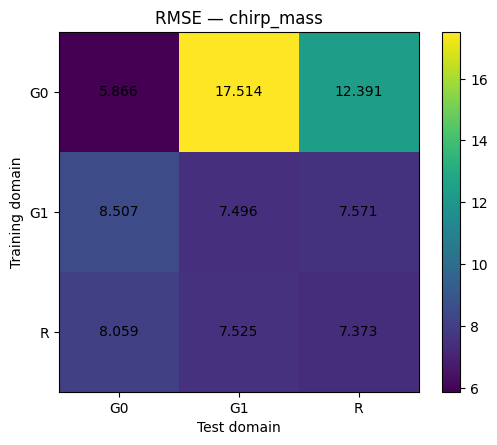

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/rmse_3x3_total_mass.png


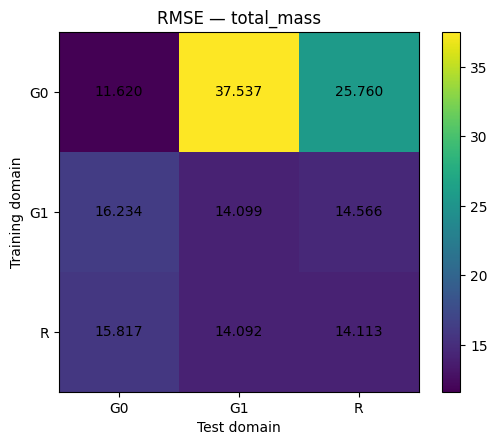

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/rmse_3x3_chi_eff.png


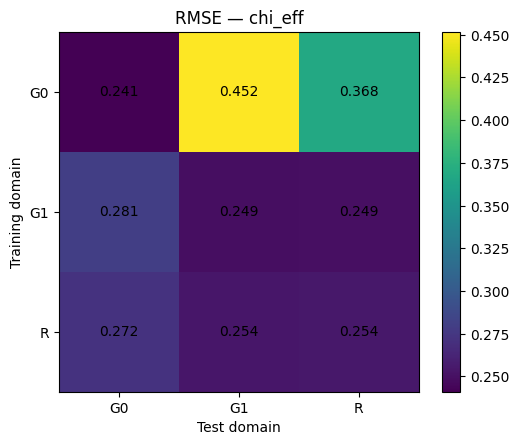

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/degradation_D_3x3_chirp_mass.png


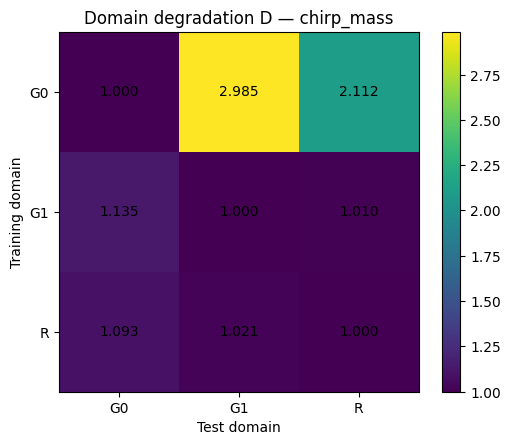

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/degradation_D_3x3_total_mass.png


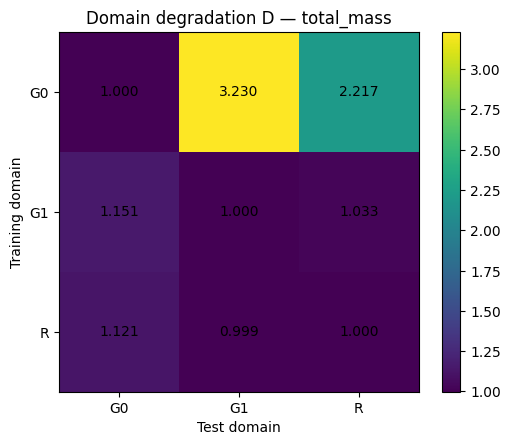

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/degradation_D_3x3_chi_eff.png


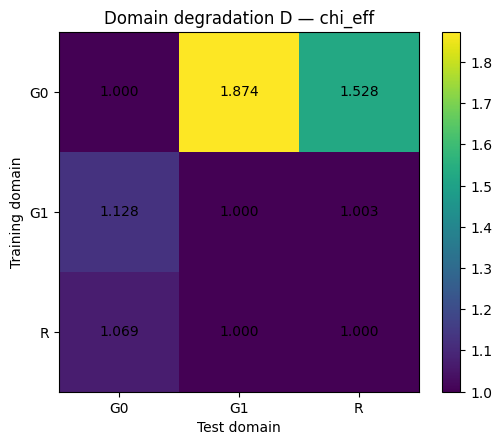

In [9]:
def plot_matrix(table, title, value_format=".3f", save_name=None):
    values = table.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(values)

    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)

    ax.set_xlabel("Test domain")
    ax.set_ylabel("Training domain")
    ax.set_title(title)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(
                j,
                i,
                format(values[i, j], value_format),
                ha="center",
                va="center",
            )

    fig.colorbar(im, ax=ax)
    fig.tight_layout()

    if save_name is not None:
        path = OUT_DIR / save_name
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


for label in first["label_names"]:
    plot_matrix(
        metric_tables[(label, "RMSE")],
        title=f"RMSE — {label}",
        save_name=f"rmse_3x3_{label}.png",
    )

for label in first["label_names"]:
    plot_matrix(
        D_tables[label],
        title=f"Domain degradation D — {label}",
        save_name=f"degradation_D_3x3_{label}.png",
    )


## 8. Real-domain residual comparison

Residuals are defined as

$$
r = \hat{y} - y.
$$

Only the three models evaluated on the **same real test set** are compared here, which preserves the paired experimental design.


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/residual_hist_real_chirp_mass.png


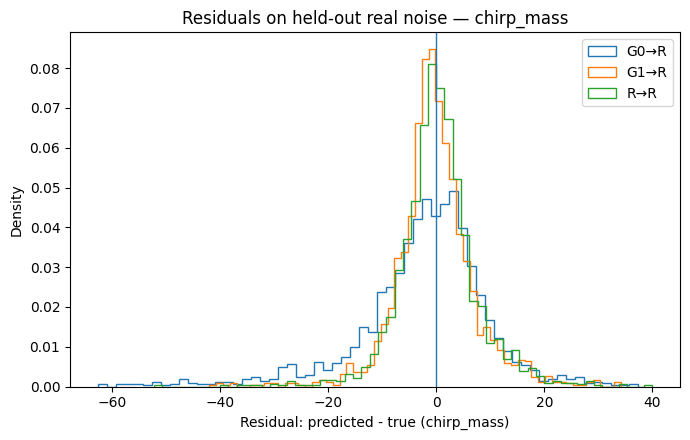

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/residual_hist_real_total_mass.png


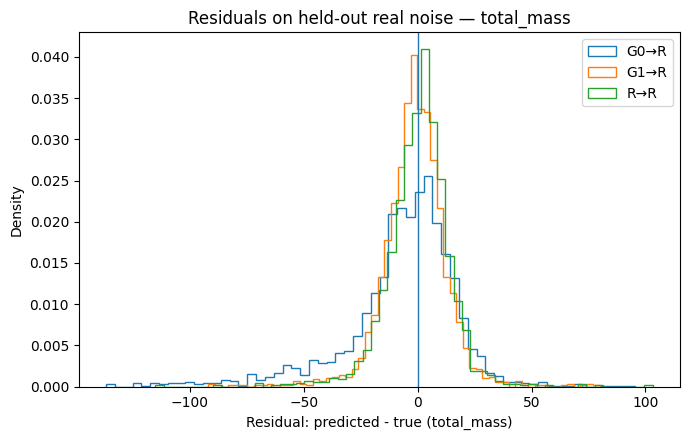

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/residual_hist_real_chi_eff.png


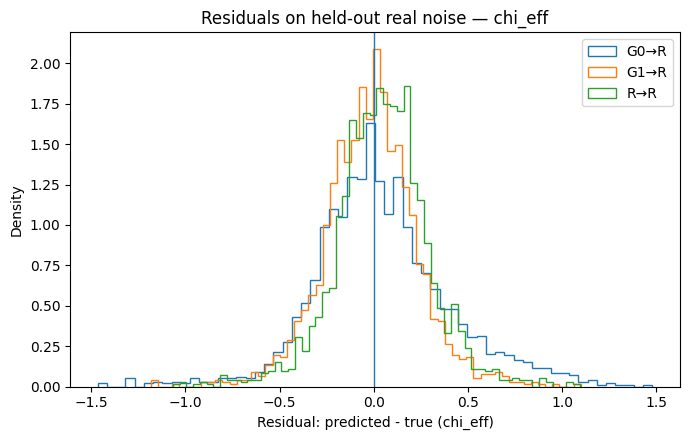

In [10]:
for j, label in enumerate(first["label_names"]):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for train_domain in DOMAINS:
        run = runs[(train_domain, "R")]
        residual = run["pred_phys"][:, j] - run["y_true_phys"][:, j]
        ax.hist(
            residual,
            bins=60,
            histtype="step",
            density=True,
            label=f"{train_domain}→R",
        )

    ax.axvline(0.0, linewidth=1)
    ax.set_xlabel(f"Residual: predicted - true ({label})")
    ax.set_ylabel("Density")
    ax.set_title(f"Residuals on held-out real noise — {label}")
    ax.legend()
    fig.tight_layout()

    path = OUT_DIR / f"residual_hist_real_{label}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


## 9. Prediction vs truth on real test data

The same real test samples are used for G0→R, G1→R and R→R.


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_G0_to_R_chirp_mass.png


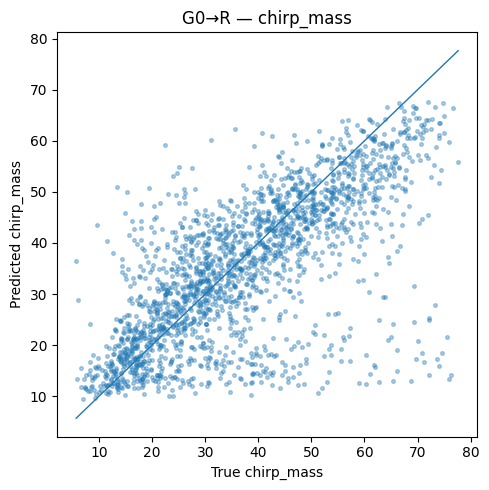

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_G1_to_R_chirp_mass.png


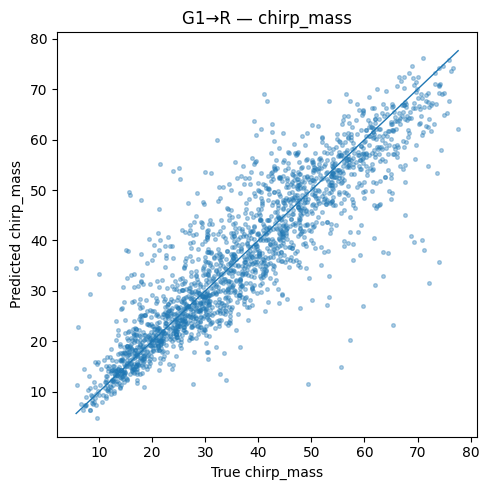

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_R_to_R_chirp_mass.png


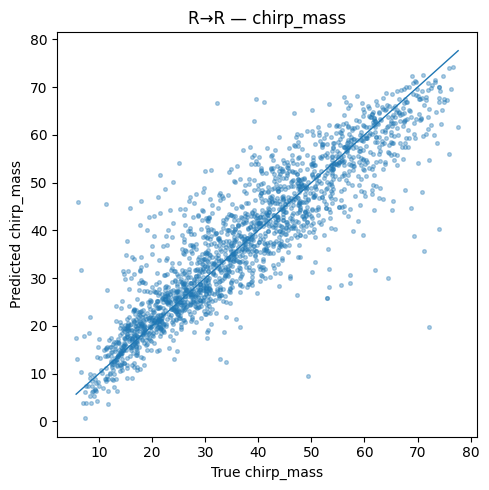

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_G0_to_R_total_mass.png


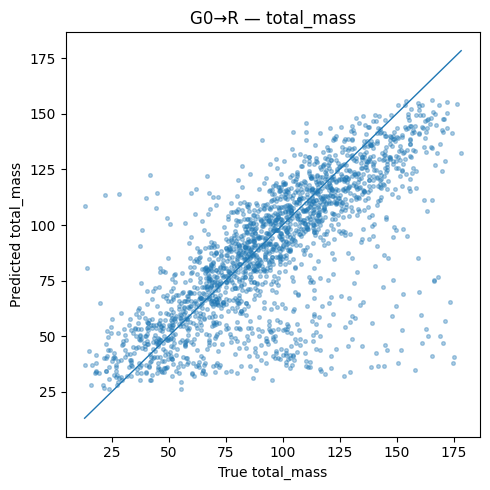

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_G1_to_R_total_mass.png


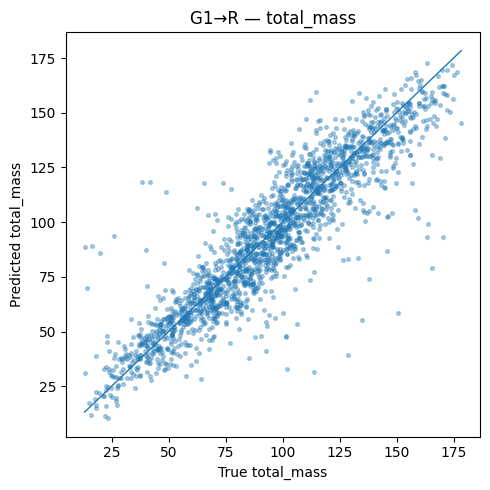

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_R_to_R_total_mass.png


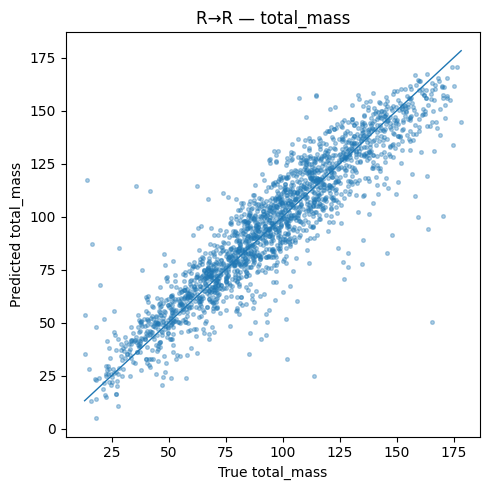

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_G0_to_R_chi_eff.png


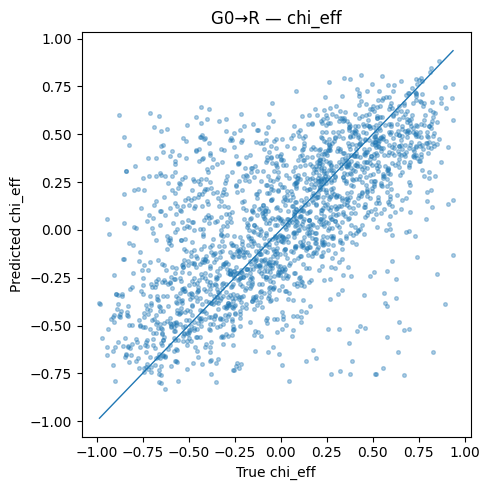

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_G1_to_R_chi_eff.png


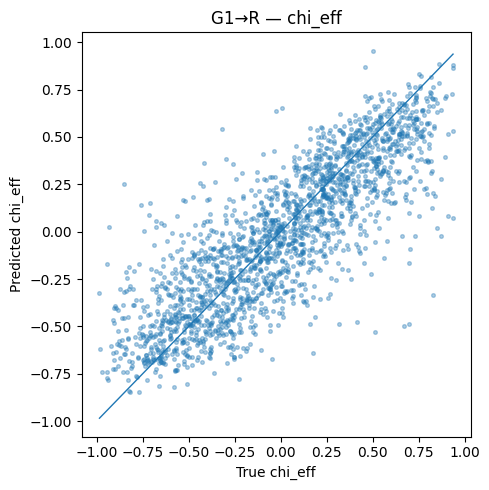

Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/pred_vs_true_R_to_R_chi_eff.png


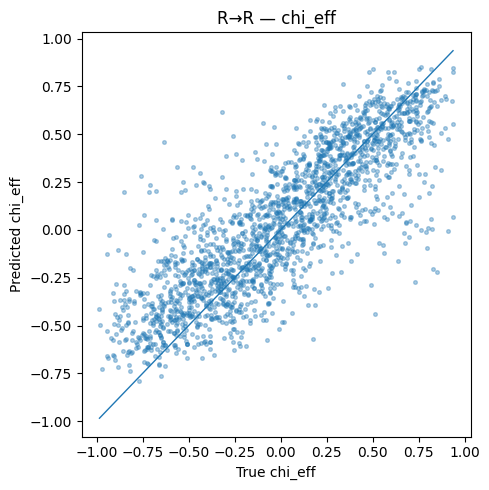

In [11]:
for j, label in enumerate(first["label_names"]):
    y_true = runs[("G0", "R")]["y_true_phys"][:, j]

    lo = float(np.min(y_true))
    hi = float(np.max(y_true))

    for train_domain in DOMAINS:
        pred = runs[(train_domain, "R")]["pred_phys"][:, j]

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(y_true, pred, s=7, alpha=0.35)
        ax.plot([lo, hi], [lo, hi], linewidth=1)

        ax.set_xlabel(f"True {label}")
        ax.set_ylabel(f"Predicted {label}")
        ax.set_title(f"{train_domain}→R — {label}")
        fig.tight_layout()

        path = OUT_DIR / f"pred_vs_true_{train_domain}_to_R_{label}.png"
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print("Saved:", path)
        plt.show()


## 10. Compact summary table

This table is intended to be the first object inspected when interpreting M11.6.


In [12]:
summary = metrics_df[
    metrics_df["test_domain"] == "R"
][
    ["train_domain", "label", "RMSE", "MAE", "bias", "R2"]
].copy()

summary = summary.merge(
    key_df[["label", "I_PSD", "I_R"]],
    on="label",
    how="left",
)

display(summary)

summary_csv = OUT_DIR / "m11_8_real_domain_summary.csv"
summary.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)


,train_domain,label,RMSE,MAE,bias,R2,I_PSD,I_R
0,G0,chirp_mass,12.390531,8.535120,-2.283666,0.427633,0.388940,0.026191
1,G0,total_mass,25.760461,17.285395,-6.616973,0.436438,0.434573,0.031106
2,G0,chi_eff,0.368412,0.271602,0.040880,0.325848,0.323129,-0.020006
3,G1,chirp_mass,7.571356,5.231518,-0.202097,0.786282,0.388940,0.026191
4,G1,total_mass,14.565664,10.103608,-1.320127,0.819825,0.434573,0.031106
5,G1,chi_eff,0.249368,0.188335,-0.016828,0.691134,0.323129,-0.020006
6,R,chirp_mass,7.373054,5.132074,0.353190,0.797330,0.388940,0.026191
7,R,total_mass,14.112579,10.010623,0.333755,0.830860,0.434573,0.031106
8,R,chi_eff,0.254357,0.191227,0.045054,0.678652,0.323129,-0.020006


Saved: /data/vserrano/cbc_pe_data/results/m11_6_domains/m11_8_cross_domain_analysis/m11_8_real_domain_summary.csv


## Interpretation checklist

Use the numerical results to answer, parameter by parameter:

1. **Is G1→R better than G0→R?**  
   If so, how much of the synthetic→real gap is attributable to using the empirical PSD rather than the analytical M10 PSD?

2. **Is R→R better than G1→R?**  
   This is the core test of whether real detector noise contains learnable structure not captured by stationary Gaussian noise with the same empirical PSD.

3. **What is the cost of real-noise training outside R?**  
   Inspect R→G0 and R→G1 relative to the corresponding in-domain baselines.

4. **Are conclusions consistent across chirp mass, total mass and effective spin?**  
   Treat each target separately; do not collapse the three regression problems into one global scalar.

5. **Do residual plots reveal regression-to-the-mean or strongly non-Gaussian tails?**  
   If present, quantify them only after the main 3×3 result is established.

The present notebook is descriptive. Statistical uncertainty that respects the clustered real-noise sampling design should be added only if required for the final quantitative claims.


# Conclusion

>M11.6 demonstrates that the dominant synthetic-to-real domain mismatch in the current parameter-estimation pipeline is associated with the noise PSD rather than with higher-order real-noise structure. Models trained on stationary Gaussian noise generated from empirical off-source PSDs generalize to held-out real strain with only a 0.3–3.3% increase in RMSE relative to their matched synthetic domain. In contrast, the model trained using the analytical M10 PSD suffers RMSE increases of approximately 53–122% when transferred to real noise.

>Replacing the analytical PSD by empirical detector PSDs reduces the real-domain RMSE by approximately 32–44%, while subsequent replacement of Gaussian empirical-PSD noise by actual real noise changes RMSE by only −2% to +3%. Within the present preprocessing pipeline, therefore, direct training on real noise provides no clear additional advantage over empirical-PSD Gaussian training.

>This conclusion is specific to the current whitening, per-sample/per-detector z-score normalization, source population, SNR range and regression targets, and does not imply that non-Gaussian or non-stationary detector noise is generally irrelevant.